### Detección de spam
#### Automatización mediante machine learning para filtrar spam
- adaptabilidad
- presición 
- automatización

#### regla de bayes
- es una formula que describe como actualizar las probabilidades de hipótesis cuando dispone de nueva evidencia

- P(A|B) = P(B|A) * P(A) / P(B)
donde:
- P(A|B) es la probabilidad de A dado B
- P(B|A) es la probabilidad de B dado A
- P(A) es la probabilidad previa de A
- P(B) es la probabilidad total de B 

#### naive bayes
- es una aplicación del teorema de bayes con la asunción "naive" de que las características son independientes entre sí
- P(A|B1, B2, ..., Bn) = P(A) * P(B1|A) * P(B2|A) * ... * P(Bn|A) / P(B1, B2, ..., Bn)
- se utiliza en clasificación de texto, detección de spam, análisis de sentimientos, etc.

#### modelo según distribución de datos
- Gaussiano para datos en forma de camana: si los datos tienen una distribución normal (o gaussiana), ejemplo, medidas de altura, peso..

- Datos de conteno(PNL): si estas trabajando con datos que representan conteos, como la frecuencia de palabras, documentos

- Bernoulli para datos binarios: si los datos son binarios o representan la presencias/ausencia de caracteristicas


In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

# leer datos
df = pd.read_csv(r'C:\Users\ander\Escritorio\PYTHON\Python 2025\Procesamiento_lenguaje_natural_NLP\datasets\spam.csv', encoding='ISO-8859-1')
df = df[['v1', 'v2']]
df.rename(columns = {'v1': 'label', 'v2': 'email'}, inplace = True)
df.head()

,label,email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df['email'][1]

'Ok lar... Joking wif u oni...'

In [3]:
df.tail()

,label,email
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [4]:
df.shape

(5572, 2)

In [5]:
# agrupando por label
df_grouped = df.groupby('label').count()
df_grouped

,email
label,
ham,4825
spam,747


<Axes: >

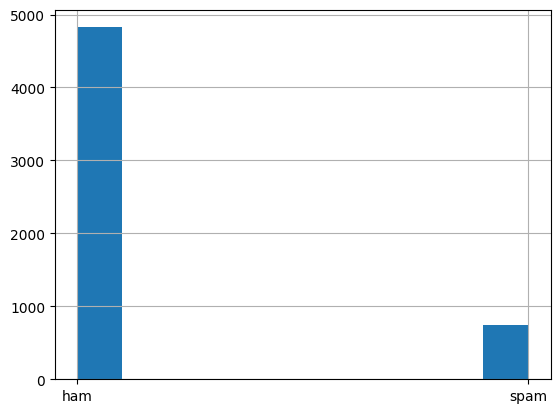

In [6]:
df['label'].hist()

In [7]:
# crear etiquetas binarias
df['b_label'] = df['label'].map({'ham': 0, 'spam': 1})
# transformar a numpy arrays
Y = df['b_label'].to_numpy()    

In [8]:
df

,label,email,b_label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [9]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [10]:
# dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df['email'], Y, test_size=0.33, random_state=42)

In [11]:
# entrenamiento
X_train

3235    Aight text me when you're back at mu and I'll ...
945     I cant wait to see you! How were the photos we...
5319                         Kothi print out marandratha.
5528    Its just the effect of irritation. Just ignore it
247                       Kallis wont bat in 2nd innings.
                              ...                        
3772    I came hostel. I m going to sleep. Plz call me...
5191                               Sorry, I'll call later
5226        Prabha..i'm soryda..realy..frm heart i'm sory
5390                           Nt joking seriously i told
860                   In work now. Going have in few min.
Name: email, Length: 3733, dtype: object

In [12]:
# prueba
X_test

3245    Funny fact Nobody teaches volcanoes 2 erupt, t...
944     I sent my scores to sophas and i had to do sec...
1044    We know someone who you know that fancies you....
2484    Only if you promise your getting out as SOON a...
812     Congratulations ur awarded either å£500 of CD ...
                              ...                        
4944    Anyway I don't think I can secure anything up ...
3313    Oh gei. That happend to me in tron. Maybe ill ...
3652    It has issues right now. Ill fix for her by to...
14                    I HAVE A DATE ON SUNDAY WITH WILL!!
4758    Thanks 4 your continued support Your question ...
Name: email, Length: 1839, dtype: object

In [13]:
# transormar texto a vectores
vectores = CountVectorizer(decode_error='ignore', stop_words='english')
X_train_counts = vectores.fit_transform(X_train)
X_test_counts = vectores.transform(X_test)

In [14]:
X_train_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 29001 stored elements and shape (3733, 6798)>

In [15]:
X_test_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12656 stored elements and shape (1839, 6798)>

In [16]:
# creando un modelo multinomialNB
modelo = MultinomialNB()
modelo.fit(X_train_counts, y_train)
print(f'train accuracy: {modelo.score(X_train_counts, y_train)}')
print(f'test accuracy: {modelo.score(X_test_counts, y_test)}')


train accuracy: 0.995713903027056
test accuracy: 0.9815116911364872


In [17]:
# ajuste del modelo
p_train = modelo.predict(X_train_counts)
p_test = modelo.predict(X_test_counts)
print(f'train f1 score: {f1_score(y_train, p_train)}')
print(f'test f1 score: {f1_score(y_test, p_test)}')

train f1 score: 0.9838709677419355
test f1 score: 0.9314516129032258


In [ ]:
# matrix de confusion para los datos de prueba
cm = confusion_matrix(y_test, p_test)
cm

array([[1574,   13],
       [  21,  231]])

In [21]:
# martriz de confusion para datos de entrenamiento
cm_train = confusion_matrix(y_train, p_train) 
cm_train

array([[3229,    9],
       [   7,  488]])

In [ ]:
# graficar matrix de confusion
def plot_cm(cm, title='Confusion Matrix', labels=['ham', 'spam']):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(title)
    plt.show()